# 24 aprile 2019 — reazione oraria alla nube di polvere

Come reagisce il modello **ora per ora** mentre la polvere arriva e se ne va.

Due scelte metodologiche, senza le quali il grafico misurerebbe altro:

**Le fasce sono definite sulla produzione attesa, non su quella realizzata.**
La produzione realizzata è l'esito: durante l'evento un nodo scivola nella
fascia bassa *proprio perché* la polvere l'ha colpito, quindi una linea per la
fascia alta descriverebbe i nodi risparmiati invece della reazione del modello.
L'atteso è la produzione dello stesso nodo alla stessa ora nei giorni tranquilli
precedenti: l'appartenenza alla fascia resta indipendente dall'evento.

**L'errore è relativo all'atteso e con segno.** Relativo perché l'errore in watt
cresce col sole e altrimenti si leggerebbe soprattutto l'alba; con segno perché
il punto è che la previsione è troppo alta all'arrivo e troppo bassa
all'uscita — l'errore assoluto cancellerebbe esattamente ciò che si vuole vedere.

Limite dichiarato: i nodi vengono colpiti in ore diverse, quindi sull'asse del
calendario il passaggio da sovrastima a sottostima appare più graduale di quanto
sia sul singolo nodo. La figura complementare, allineata sull'ora di arrivo di
ciascun nodo, sta nel notebook degli eventi estremi.

In [1]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'physiq_pv').is_dir():
    raise FileNotFoundError('Avviare il notebook dalla root del repository o da notebooks/.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import physiq_pv.reporting.event_onset as event_onset
import physiq_pv.reporting.hourly_event_response as hourly_event_response
import physiq_pv.reporting.report_dump as report_dump

event_onset = importlib.reload(event_onset)
hourly_event_response = importlib.reload(hourly_event_response)
report_dump = importlib.reload(report_dump)

RUNS = {
    'con pv_lag': 'pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1',
    'senza pv_lag': 'pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1',
}
MAIN_RUN = 'con pv_lag'

run_dirs = {name: ROOT / 'outputs' / value for name, value in RUNS.items()}
out_dir = run_dirs[MAIN_RUN]
for name, folder in run_dirs.items():
    ok = (folder / 'predictions.csv').is_file()
    print(f"{name:14s} {'OK      ' if ok else 'MANCANTE'} {folder}")
if not (out_dir / 'predictions.csv').is_file():
    raise FileNotFoundError(out_dir / 'predictions.csv')

con pv_lag     OK       /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1
senza pv_lag   OK       /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1


## 1. Finestra

I giorni dell'evento e i giorni tranquilli che costruiscono il riferimento. Il
21 aprile è escluso: la frazione regionale di nodi anomali sale già quel giorno,
quindi tenerlo nella baseline abbasserebbe l'atteso e nasconderebbe il calo.

In [2]:
EVENT_DAYS = ['2019-04-22', '2019-04-23', '2019-04-24',
              '2019-04-25', '2019-04-26', '2019-04-27']
EXCLUDE_DAYS = ['2019-04-21']
BASELINE_DAYS = 14

window = event_onset.load_event_window(
    out_dir, event_days=EVENT_DAYS, baseline_days=BASELINE_DAYS,
    exclude_days=EXCLUDE_DAYS,
)
giorni = window.groupby(window['day'].dt.strftime('%Y-%m-%d'))['is_event'].first()
print('Giorni tranquilli:', list(giorni[~giorni].index))
print('Giorni evento    :', list(giorni[giorni].index))
print(f'Righe caricate   : {len(window):,}')

Giorni tranquilli: ['2019-04-08', '2019-04-09', '2019-04-10', '2019-04-11', '2019-04-12', '2019-04-13', '2019-04-14', '2019-04-15', '2019-04-16', '2019-04-17', '2019-04-18', '2019-04-19', '2019-04-20']
Giorni evento    : ['2019-04-22', '2019-04-23', '2019-04-24', '2019-04-25', '2019-04-26', '2019-04-27']
Righe caricate   : 523,944


## 2. Profilo orario

`rel_bias` è `(previsto - reale) / atteso`: positivo significa che il modello
prevede più di quanto il nodo abbia prodotto, in proporzione a quanto avrebbe
dovuto produrre. `rel_true` e `rel_pred` sono gli stessi due livelli espressi
come quota dell'atteso, quindi `rel_true = 0.3` vuol dire che il nodo ha reso il
30% di una giornata normale a quell'ora.

In [3]:
response = hourly_event_response.build_hourly_response(window)
profile = response['profile']

print('Fasce presenti:', response['bands'])
print('Nodi           :', response['n_nodes'])
display(profile.head(12))

# Ore dell'evento, fascia attesa piu alta: e' li che l'effetto e' piu grande.
top_band = response['bands'][-1]
event_rows = profile[(profile['band'] == top_band) & profile['is_event']]
display(
    event_rows[['timestamp', 'n', 'rel_true', 'rel_pred', 'rel_bias_median',
                'rel_bias_q1', 'rel_bias_q3', 'picp']]
    .set_index('timestamp').round(3)
)

Fasce presenti: ['atteso_0_25', 'atteso_25_50', 'atteso_50_75', 'atteso_75_100']
Nodi           : 1149


,timestamp,band,n,rel_bias_mean,rel_bias_median,rel_bias_q1,rel_bias_q3,rel_bias_p10,rel_bias_p90,mae,rel_mae,rel_true,rel_pred,mean_reference,picp,is_event
0,2019-04-08 05:10:00,atteso_0_25,538,-0.036381,-0.011460,-0.089237,0.020354,-0.130495,0.035661,0.422628,0.058662,0.075949,0.039568,6.783340,0.992565,False
1,2019-04-08 06:10:00,atteso_0_25,1084,-0.496441,-0.636047,-0.710856,-0.388731,-0.770889,0.052339,50.600200,0.553239,1.070805,0.574363,87.137796,0.441882,False
2,2019-04-08 07:10:00,atteso_0_25,59,0.641631,0.600417,0.281979,0.763760,-0.071246,1.338070,56.375263,0.677134,0.882214,1.523845,90.563481,1.000000,False
3,2019-04-08 08:10:00,atteso_0_25,6,1.133474,1.291351,0.635256,1.582066,0.341128,1.767943,119.232874,1.133474,1.109791,2.243265,109.163846,1.000000,False
4,2019-04-08 14:10:00,atteso_0_25,3,1.286932,1.105218,1.088606,1.394400,1.078640,1.567910,180.054493,1.286932,1.249729,2.536661,140.801281,0.666667,False
5,2019-04-08 15:10:00,atteso_0_25,31,1.488076,1.591443,1.098952,2.142195,0.401494,2.302636,160.379909,1.488076,0.969307,2.457383,110.093573,0.838710,False
6,2019-04-08 16:10:00,atteso_0_25,158,0.881853,0.870421,0.455279,1.290157,0.073336,1.634840,75.136536,0.914703,0.784673,1.666527,84.022843,0.924051,False
7,2019-04-08 17:10:00,atteso_0_25,1149,-0.002578,-0.115204,-0.213025,0.194635,-0.307236,0.484596,11.526024,0.258428,0.885216,0.882638,46.849749,0.986075,False
8,2019-04-09 05:10:00,atteso_0_25,538,-0.020102,-0.021011,-0.066960,0.037831,-0.148607,0.075801,0.507992,0.075229,0.143844,0.123741,6.783340,0.973978,False
9,2019-04-09 06:10:00,atteso_0_25,1084,-0.176148,-0.317805,-0.377089,-0.061550,-0.416707,0.376223,28.914439,0.339500,1.085966,0.909818,87.137796,0.994465,False


,n,rel_true,rel_pred,rel_bias_median,rel_bias_q1,rel_bias_q3,picp
timestamp,,,,,,,
2019-04-22 08:10:00,352,0.907,0.822,-0.081,-0.268,0.088,0.966
2019-04-22 09:10:00,1112,1.081,0.981,-0.118,-0.219,0.014,0.984
2019-04-22 10:10:00,1143,1.106,1.112,-0.008,-0.134,0.154,0.942
2019-04-22 11:10:00,1119,1.057,1.085,0.020,-0.138,0.182,0.951
2019-04-22 12:10:00,1034,0.872,1.022,0.129,-0.026,0.290,0.909
2019-04-22 13:10:00,939,0.583,0.820,0.241,0.009,0.459,0.853
2019-04-22 14:10:00,331,0.336,0.575,0.290,0.195,0.391,0.937
2019-04-22 15:10:00,8,0.427,0.591,0.200,0.073,0.284,1.000
2019-04-23 08:10:00,352,0.327,0.459,0.160,0.060,0.245,0.994


## 3. Figure

Un pannello per fascia attesa: linea continua = mediana del bias relativo,
punteggiata = media, banda scura = Q1–Q3 fra i nodi, banda chiara = P10–P90. I
cerchietti vuoti marcano le ore calcolate su meno di `MIN_N` nodi, dove il
valore oscilla per numerosità e non per comportamento del modello. L'ultimo
pannello riporta `n`.

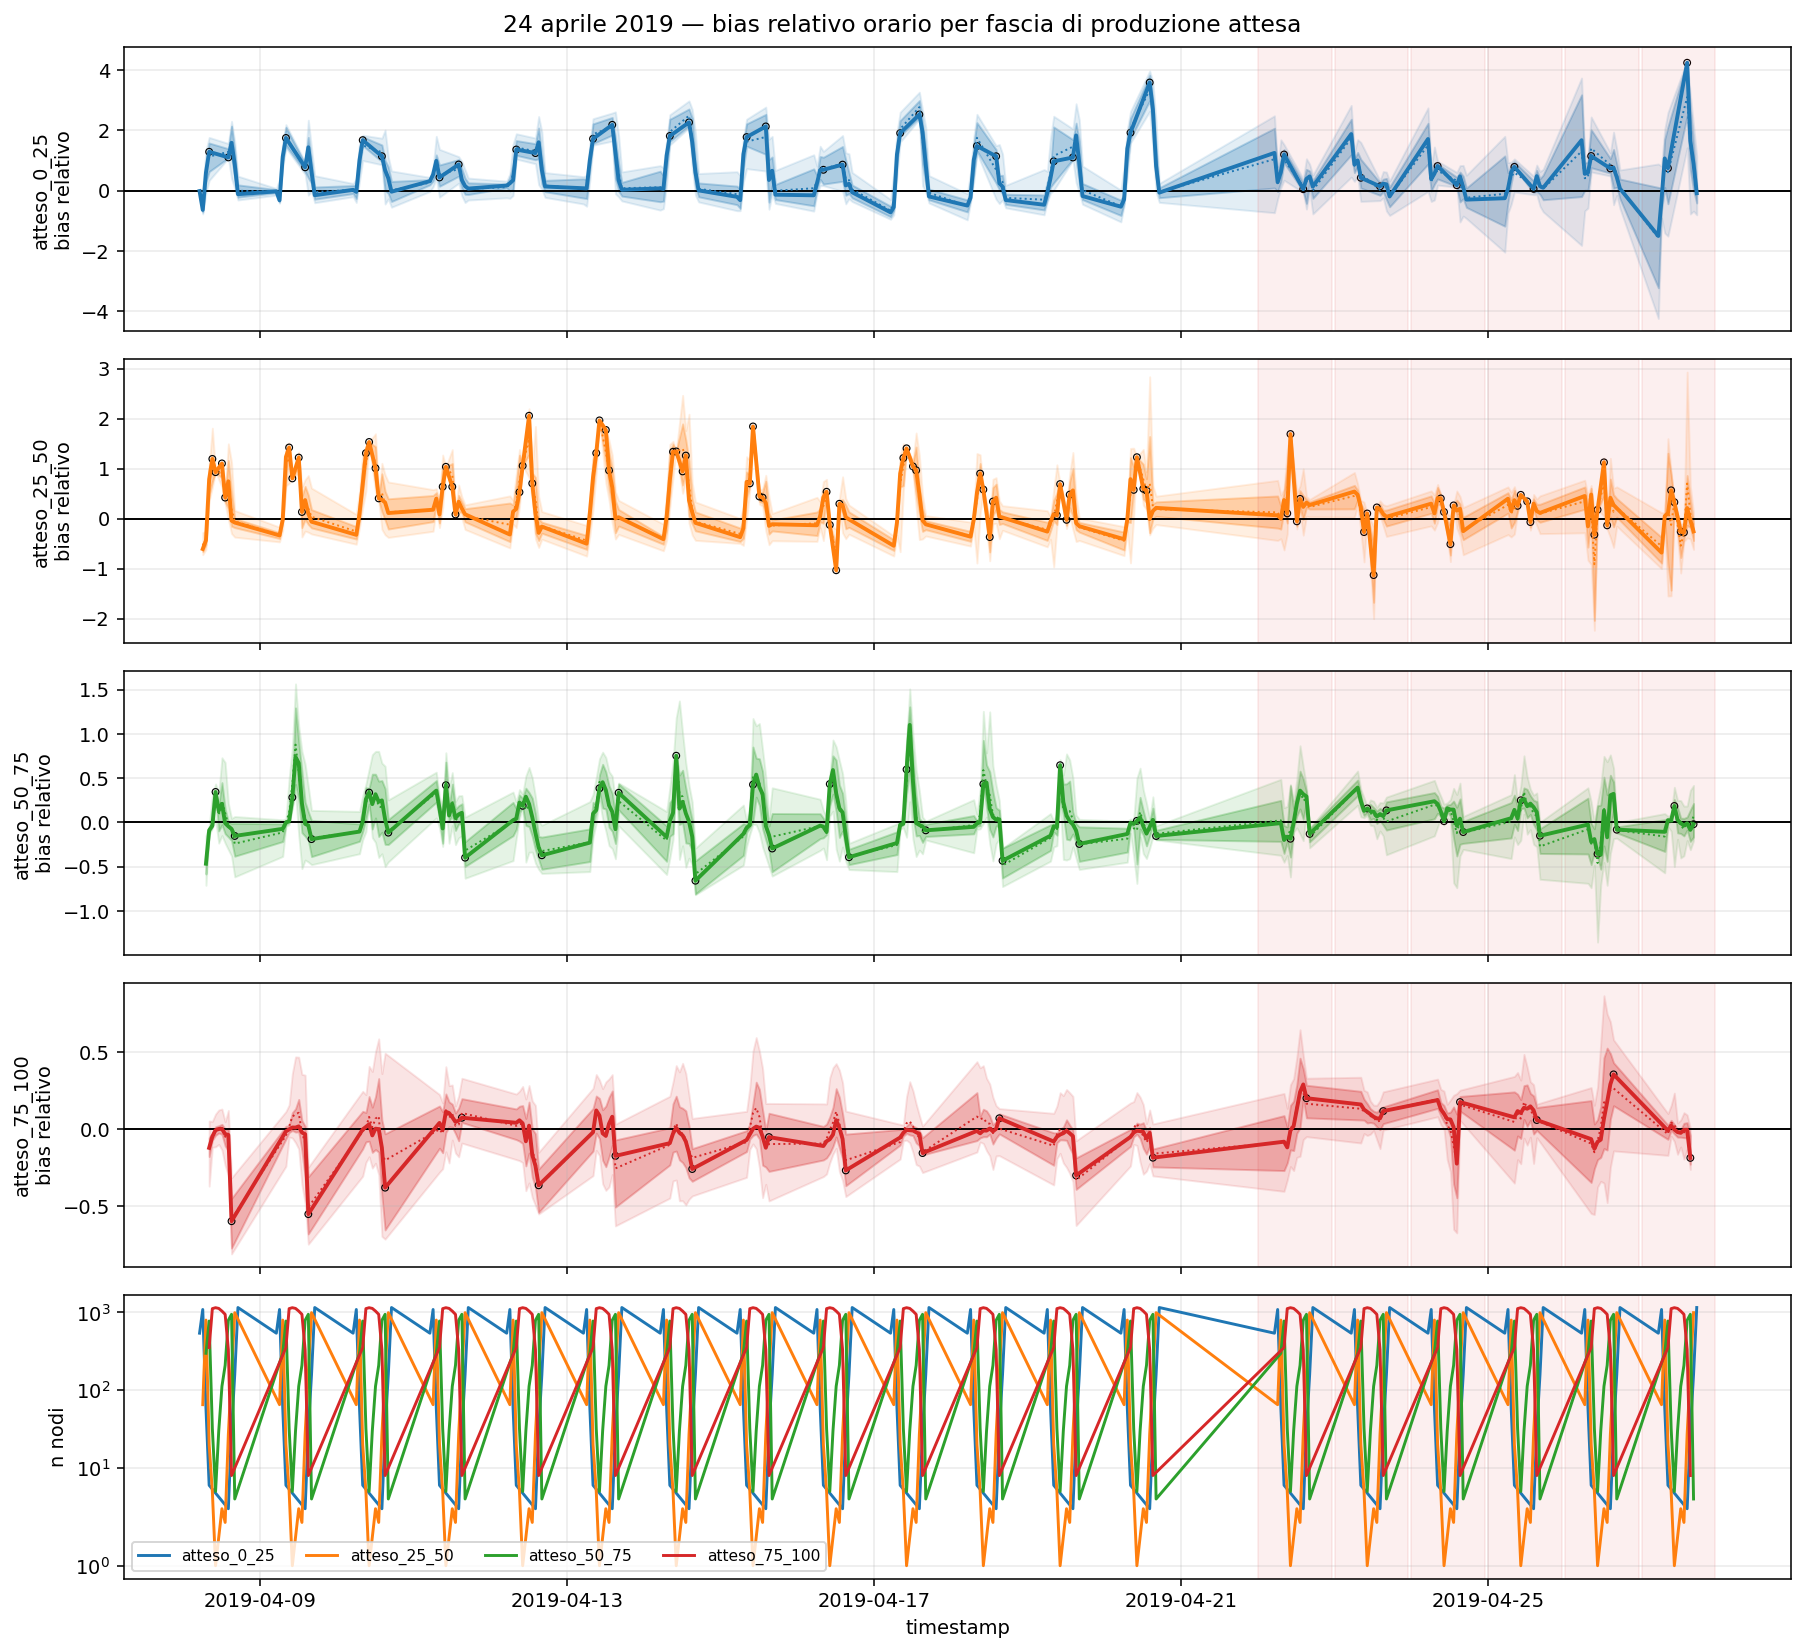

In [4]:
MIN_N = 20
figure_dir = out_dir / 'figures' / 'april_dust_hourly'
figure_dir.mkdir(parents=True, exist_ok=True)

fig = hourly_event_response.plot_hourly_response(
    response, event_days=EVENT_DAYS, min_n=MIN_N,
    title='24 aprile 2019 — bias relativo orario per fascia di produzione attesa',
)
path = figure_dir / 'hourly_relative_bias.png'
fig.savefig(path, dpi=140, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(path)))

hourly_levels_atteso_0_25.png


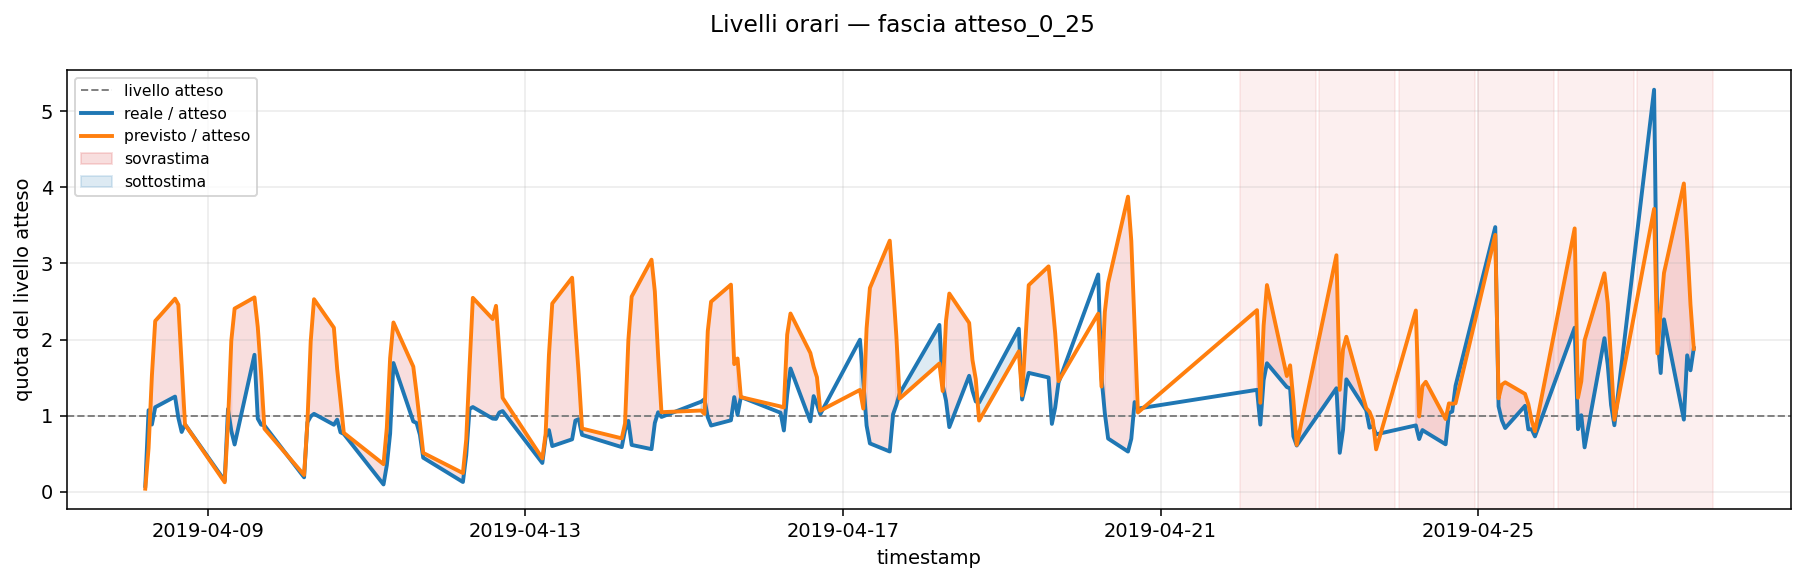

hourly_levels_atteso_25_50.png


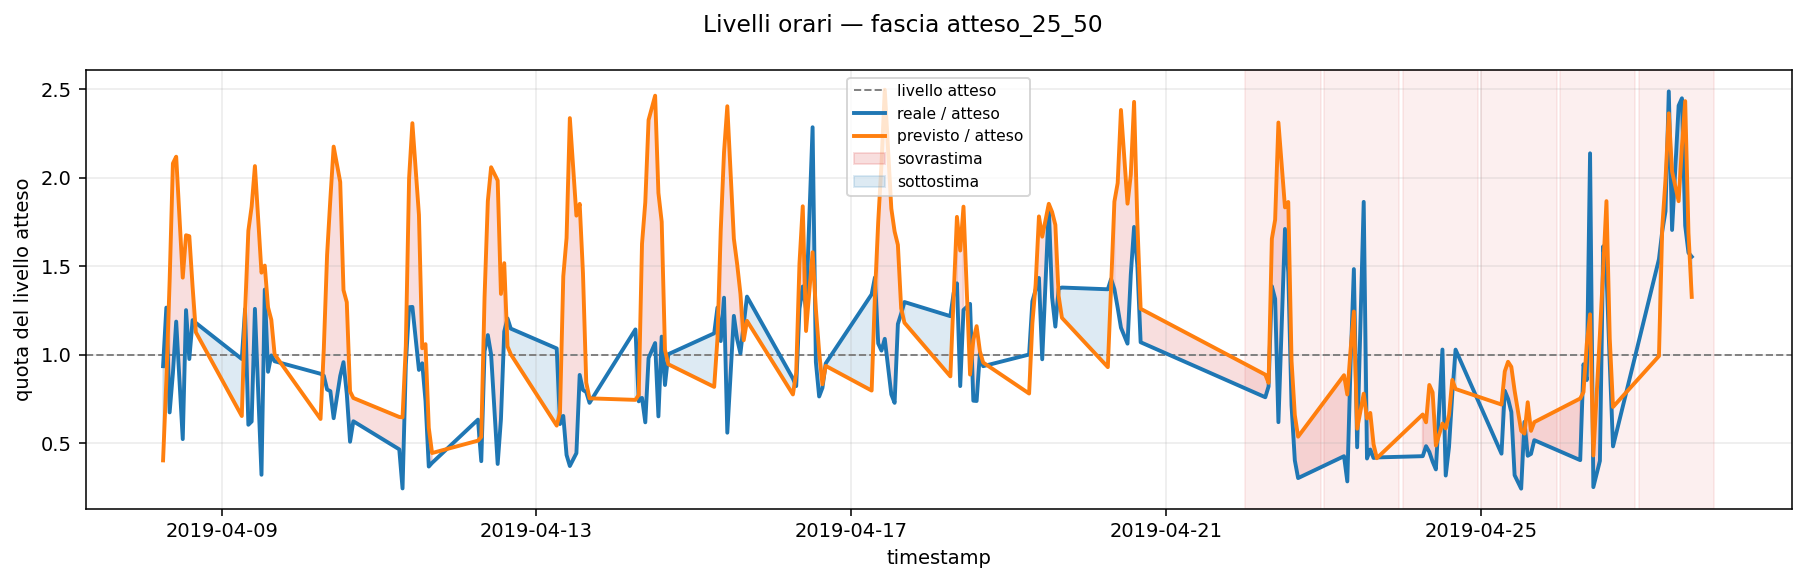

hourly_levels_atteso_50_75.png


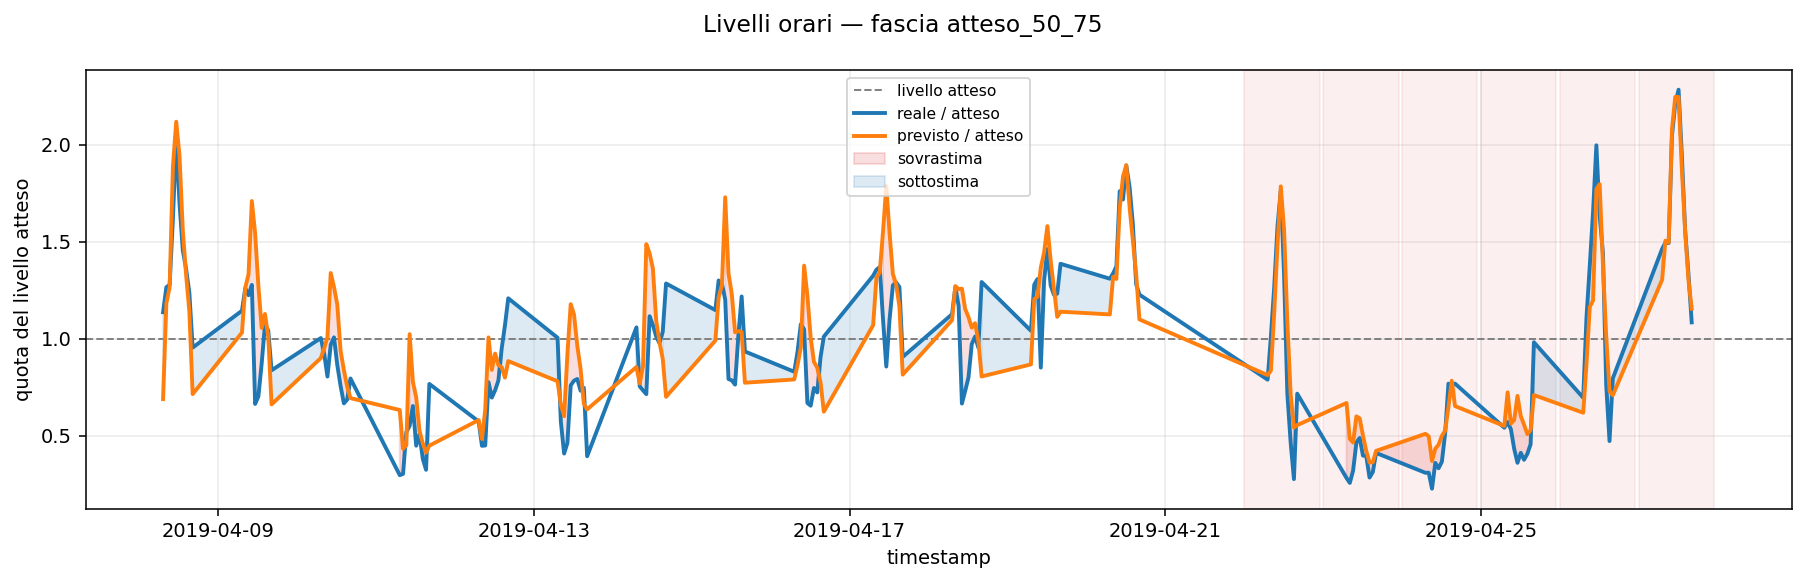

hourly_levels_atteso_75_100.png


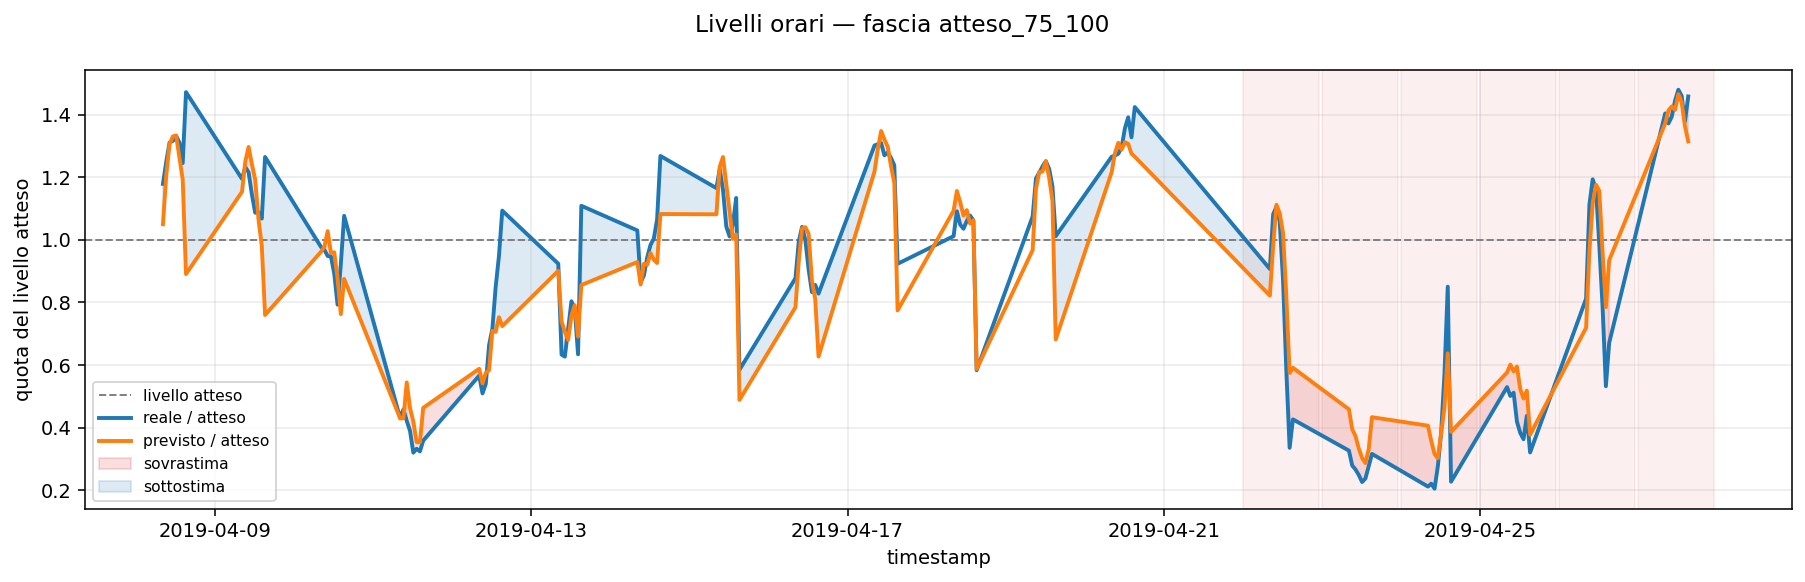

In [5]:
# Livelli: quanto ha prodotto e quanto ha previsto, in quota dell'atteso.
for band in response['bands']:
    fig = hourly_event_response.plot_hourly_levels(
        response, band=band, event_days=EVENT_DAYS,
        title=f'Livelli orari — fascia {band}',
    )
    path = figure_dir / f'hourly_levels_{band}.png'
    fig.savefig(path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    print(path.name)
    display(Image(filename=str(path)))

## 4. Quando cambia segno

Il ritardo di reazione si legge come l'intervallo fra la prima ora di
sovrastima e il passaggio a sottostima, fascia per fascia.

In [6]:
rows = []
for band in response['bands']:
    block = profile[(profile['band'] == band) & profile['is_event']].sort_values('timestamp')
    block = block[block['n'] >= MIN_N]
    if block.empty:
        continue
    over = block[block['rel_bias_median'] > 0.05]
    under = block[block['rel_bias_median'] < -0.05]
    rows.append({
        'fascia': band,
        'ore_sovrastima': len(over),
        'ore_sottostima': len(under),
        'prima_sovrastima': over['timestamp'].min() if not over.empty else None,
        'picco_sovrastima': over['rel_bias_median'].max() if not over.empty else None,
        'prima_sottostima': under['timestamp'].min() if not under.empty else None,
        'picco_sottostima': under['rel_bias_median'].min() if not under.empty else None,
        'picp_min': block['picp'].min() if 'picp' in block else None,
    })
crossing = pd.DataFrame(rows)
display(crossing)

,fascia,ore_sovrastima,ore_sottostima,prima_sovrastima,picco_sovrastima,prima_sottostima,picco_sottostima,picp_min
0,atteso_0_25,30,6,2019-04-22 05:10:00,1.879184,2019-04-23 17:10:00,-1.501094,0.612903
1,atteso_25_50,29,4,2019-04-22 06:10:00,0.543290,2019-04-24 16:10:00,-0.677226,0.740741
2,atteso_50_75,27,8,2019-04-22 12:10:00,0.394019,2019-04-22 08:10:00,-0.365334,0.800000
3,atteso_75_100,25,7,2019-04-22 12:10:00,0.290476,2019-04-22 08:10:00,-0.222882,0.724371


## 5. Persistenza: il modello prevede o ripete?

Senza covariate all'ora target il miglior predittore disponibile è l'ultima
osservazione, e un modello può limitarsi a riprodurla. Il confronto è **per
nodo**: per ogni località e ora si misura quanto la previsione dista dalla
produzione dell'ora che deve prevedere e da quella dell'ora precedente.

- `rapporto > 1` → la previsione è più vicina all'ora **precedente**: persistenza;
- `rapporto < 1` → è più vicina all'ora **corrente**: il modello anticipa davvero.

Le colonne `_transizioni` restringono alle ore in cui la produzione si è mossa
davvero, dove persistenza e previsione divergono; nelle ore stabili le due cose
coincidono per costruzione e il test non distingue nulla.

`pv_lag_pvgis` porta in input la produzione delle ore precedenti ed è il
sospetto naturale. La run senza quella feature dice se è lei la causa.

In [7]:
checks = {}
responses = {MAIN_RUN: response}

for name, folder in run_dirs.items():
    if name == MAIN_RUN:
        continue
    if not (folder / 'predictions.csv').is_file():
        print(f'[skip] {name}: predictions.csv assente')
        continue
    other_window = event_onset.load_event_window(
        folder, event_days=EVENT_DAYS, baseline_days=BASELINE_DAYS,
        exclude_days=EXCLUDE_DAYS,
    )
    responses[name] = hourly_event_response.build_hourly_response(other_window)

for name, item in responses.items():
    check = hourly_event_response.persistence_check(item, event_only=True)
    check.insert(0, 'run', name)
    checks[name] = check

persistence = pd.concat(checks.values(), ignore_index=True)
display(persistence.round(4))

,run,band,n_ore_nodo,err_vs_ora_corrente,err_vs_ora_precedente,corr_ora_corrente,corr_ora_precedente,n_transizioni,rapporto,err_vs_corrente_transizioni,err_vs_precedente_transizioni,rapporto_transizioni
0,con pv_lag,tutte,79062,0.2706,0.2667,0.7783,0.7171,41295,1.0146,0.3697,0.3615,1.0228
1,con pv_lag,atteso_0_25,11430,0.5268,0.7656,0.5160,0.4292,9198,0.6881,0.5524,0.8496,0.6501
2,con pv_lag,atteso_25_50,12282,0.3140,0.3069,0.7452,0.7805,7677,1.0233,0.3502,0.3390,1.0330
3,con pv_lag,atteso_50_75,19122,0.2558,0.2069,0.8438,0.8937,10168,1.2365,0.3196,0.2296,1.3922
4,con pv_lag,atteso_75_100,36228,0.1828,0.1272,0.8845,0.9534,14252,1.4368,0.2981,0.1527,1.9529
5,senza pv_lag,tutte,79062,0.2667,0.2651,0.7823,0.7015,41295,1.0060,0.3689,0.3669,1.0054
6,senza pv_lag,atteso_0_25,11430,0.5249,0.8275,0.5201,0.3564,9198,0.6343,0.5320,0.9080,0.5859
7,senza pv_lag,atteso_25_50,12282,0.3125,0.3023,0.7439,0.7905,7677,1.0336,0.3505,0.3337,1.0504
8,senza pv_lag,atteso_50_75,19122,0.2503,0.1914,0.8406,0.9022,10168,1.3080,0.3250,0.2173,1.4957
9,senza pv_lag,atteso_75_100,36228,0.1783,0.1140,0.8814,0.9560,14252,1.5646,0.3050,0.1424,2.1413


In [8]:
# Sintesi sulle sole transizioni: e' li che il test discrimina.
overall = persistence[persistence['band'] == 'tutte']
columns = [c for c in ('run', 'n_ore_nodo', 'err_vs_ora_corrente', 'err_vs_ora_precedente',
                       'rapporto', 'n_transizioni', 'err_vs_corrente_transizioni',
                       'err_vs_precedente_transizioni', 'rapporto_transizioni',
                       'corr_ora_corrente', 'corr_ora_precedente') if c in overall]
display(overall[columns].round(4).set_index('run'))

for _, row in overall.iterrows():
    verdetto = 'PERSISTENZA' if row['rapporto'] > 1 else 'anticipa'
    extra = ''
    if 'rapporto_transizioni' in row and pd.notna(row['rapporto_transizioni']):
        extra = f", sulle transizioni {row['rapporto_transizioni']:.2f}"
    print(f"{row['run']:14s} rapporto {row['rapporto']:.2f}{extra} -> {verdetto}")

,n_ore_nodo,err_vs_ora_corrente,err_vs_ora_precedente,rapporto,n_transizioni,err_vs_corrente_transizioni,err_vs_precedente_transizioni,rapporto_transizioni,corr_ora_corrente,corr_ora_precedente
run,,,,,,,,,,
con pv_lag,79062,0.2706,0.2667,1.0146,41295,0.3697,0.3615,1.0228,0.7783,0.7171
senza pv_lag,79062,0.2667,0.2651,1.0060,41295,0.3689,0.3669,1.0054,0.7823,0.7015


con pv_lag     rapporto 1.01, sulle transizioni 1.02 -> PERSISTENZA
senza pv_lag   rapporto 1.01, sulle transizioni 1.01 -> PERSISTENZA


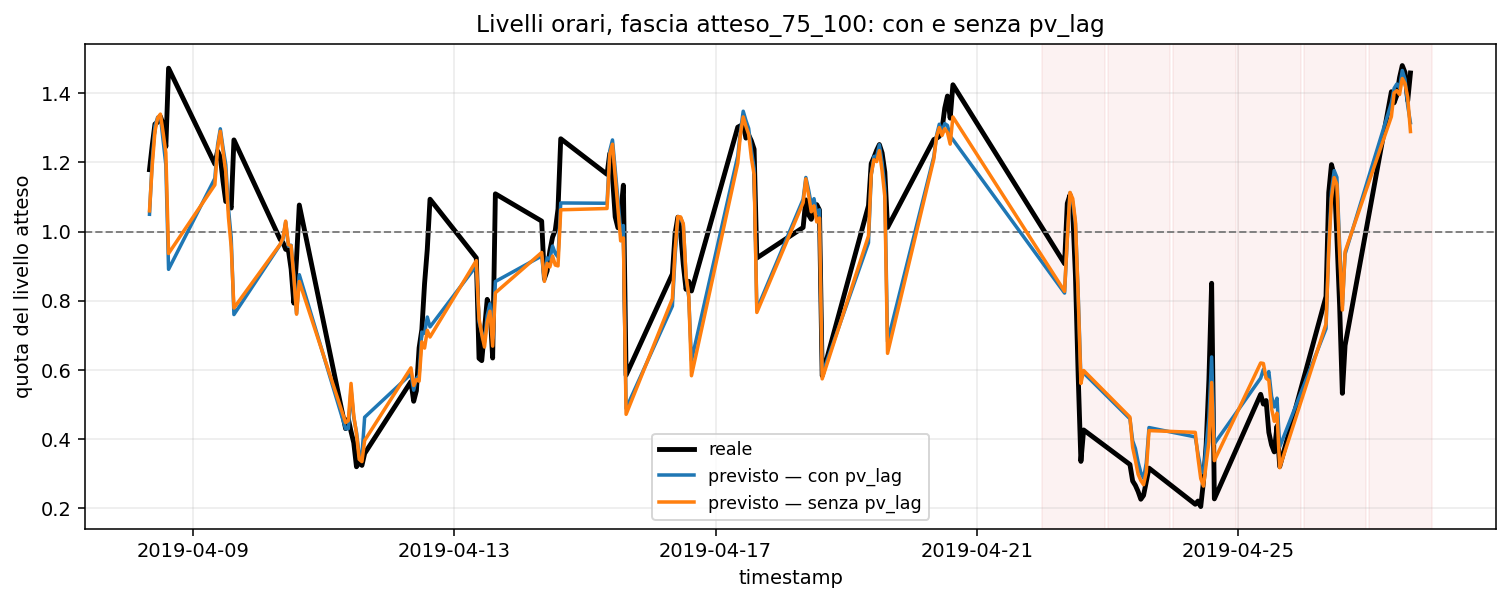

In [9]:
# Livelli orari delle due run sulla fascia attesa piu alta, sovrapposti.
if len(responses) > 1:
    fig, axis = plt.subplots(figsize=(13, 4.5))
    first = True
    for name, item in responses.items():
        block = item['profile']
        block = block[block['band'] == top_band].sort_values('timestamp')
        if first:
            axis.plot(block['timestamp'], block['rel_true'], lw=2.5,
                      color='black', label='reale')
            axis.axhline(1.0, color='grey', ls='--', lw=1)
            first = False
        axis.plot(block['timestamp'], block['rel_pred'], lw=1.8, label=f'previsto — {name}')
    for day in EVENT_DAYS:
        start = pd.Timestamp(day).normalize()
        axis.axvspan(start, start + pd.Timedelta(hours=23), color='tab:red', alpha=0.06)
    axis.set(ylabel='quota del livello atteso', xlabel='timestamp',
             title=f'Livelli orari, fascia {top_band}: con e senza pv_lag')
    axis.grid(alpha=0.25)
    axis.legend(fontsize=9)
    path = figure_dir / 'hourly_levels_pv_lag_comparison.png'
    fig.savefig(path, dpi=140, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))

## 6. Riepilogo da copiare

In [10]:
report_dump.dump_sections({
    'profilo_orario_fascia_alta': event_rows[
        ['timestamp', 'band', 'n', 'rel_true', 'rel_pred', 'rel_bias_median',
         'rel_bias_q1', 'rel_bias_q3', 'picp']
    ],
    'persistenza': persistence if 'persistence' in dir() else None,
    'cambi_di_segno': crossing if 'crossing' in dir() else None,
}, path=out_dir / 'analysis_summary_april_hourly.txt', max_rows=80)

## profilo_orario_fascia_alta
timestamp,band,n,rel_true,rel_pred,rel_bias_median,rel_bias_q1,rel_bias_q3,picp
2019-04-22 08:10:00,atteso_75_100,352,0.9072,0.8223,-0.0809,-0.2677,0.0879,0.9659
2019-04-22 09:10:00,atteso_75_100,1112,1.0815,0.9809,-0.1178,-0.2187,0.0142,0.9838
2019-04-22 10:10:00,atteso_75_100,1143,1.1064,1.1124,-0.0080,-0.1335,0.1543,0.9423
2019-04-22 11:10:00,atteso_75_100,1119,1.0570,1.0852,0.0204,-0.1384,0.1821,0.9508
2019-04-22 12:10:00,atteso_75_100,1034,0.8717,1.0222,0.1289,-0.0260,0.2897,0.9091
2019-04-22 13:10:00,atteso_75_100,939,0.5833,0.8198,0.2405,0.0090,0.4593,0.8530
2019-04-22 14:10:00,atteso_75_100,331,0.3356,0.5747,0.2895,0.1949,0.3910,0.9366
2019-04-22 15:10:00,atteso_75_100,8,0.4265,0.5914,0.2005,0.0733,0.2844,1.0000
2019-04-23 08:10:00,atteso_75_100,352,0.3267,0.4588,0.1598,0.0597,0.2450,0.9943
2019-04-23 09:10:00,atteso_75_100,1112,0.2790,0.3952,0.1272,0.0586,0.1941,0.9982
2019-04-23 10:10:00,atteso_75_100,1143,0.2663,0.3728,0.1123,0.0402,0.1657,0.990

PosixPath('/home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/analysis_summary_april_hourly.txt')